### Importando Bibliotecas Básicas

In [1]:

from datetime import datetime, timedelta
import numpy as np
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import pingouin as pg


### Exploraçao

In [2]:
# Criando um caminho universal para que rode em qualquer maquina
pasta_atual = Path.cwd()
pasta_banco = pasta_atual.parent / 'database'

In [3]:
# Carregando os arquivos e modificando os tipos de dados

contas_df = pd.read_csv(pasta_banco/'account.asc', sep=';', dtype= {'account_id':str, 'district_id': str})
cartoes_df = pd.read_csv(pasta_banco/'card.asc', sep=';', dtype= {'card_id': str,'disp_id':str})
clientes_df = pd.read_csv(pasta_banco/'client.asc', sep=';', dtype= {'client_id':str,'district_id':str, 'birth_number': str})
cliente_conta_df = pd.read_csv(pasta_banco/'disp.asc', sep=';', dtype= {'disp_id':str, 'client_id':str,'account_id':str})
emprestimo_df = pd.read_csv(pasta_banco/'loan.asc', sep=';', dtype = {'loan_id':str,'account_id':str})
ordens_df = pd.read_csv(pasta_banco/'order.asc', sep=';', dtype = {'order_id':str,'account_id':str})
distrito_df = pd.read_csv(pasta_banco/'district.asc', sep=';',na_values=['?'] ,dtype = {'A1':str,'A11':float,'A12':float,'A15':'Int64'})
transacoes_df = pd.read_csv(pasta_banco/'trans.asc', sep=';',dtype={'trans_id' : str,'account_id' : str, 'bank':str}) 


### Correção de Inconsistencias e Traduçao de Linhas e Colunas

In [4]:
# tabela contas_df

contas_df = contas_df.rename(columns={
    'account_id': 'id_conta',
    'district_id': 'id_distrito',
    'date': 'data',
    'frequency': 'frequencia'
})

ajustar = {
    'POPLATEK MESICNE': 'emissao_mensal',
    'POPLATEK PO OBRATU': 'emissao_semanal',
    'POPLATEK TYDNE': 'emissao_pos_transacao'
}


contas_df['frequencia'] = contas_df['frequencia'].replace(ajustar)
contas_df.head(2)

#-----------------------------------------------------------------------------

# tabela contas_df

cartoes_df = cartoes_df.rename(columns={
    'card_id': 'id_cartao',
    'disp_id': 'id_disp',
    'type': 'tipo_cartao',
    'issued': 'data'
})


cartoes_df.sample(10)


#-----------------------------------------------------------------------------

# tabela cliente_conta_df

cliente_conta_df = cliente_conta_df.rename(columns={
    'disp_id	': 'id_disp',
    'client_id': 'id_cliente',
    'account_id': 'id_conta',
    'type': 'tipo_acesso'
})

ajustar = {
    'OWNER': 'proprietario',
    'DISPONENT': 'usuario'
}

cliente_conta_df['tipo_acesso'] = cliente_conta_df['tipo_acesso'].replace(ajustar)
#cliente_conta_df.sample(10)
#-----------------------------------------------------------------------------

# tabela emprestimo_df

emprestimo_df = emprestimo_df.rename(columns={
    'loan_id': 'id_emprestimo',
    'account_id': 'id_conta',
    'date': 'data',
    'amount': 'valor_total',
    'duration': 'prazo_meses',
    'payments': 'valor_parcela',
    'status': 'status_pagamento'
})

ajustar = {
    'A': 'Encerrado - Quitado',
    'B': 'Encerrado - Inadimplente',
    'C': 'Ativo - Regular',
    'D': 'Ativo - Inadimplente'
}


emprestimo_df['status_pagamento'] = emprestimo_df['status_pagamento'].replace(ajustar)
#emprestimo_df.sample(10)

#-----------------------------------------------------------------------------


# tabela ordens_df

ordens_df = ordens_df.rename(columns={
    'order_id': 'id_ordem',
    'account_id': 'id_conta',
    'bank_to': 'banco_destino',
    'account_to': 'conta_destino',
    'amount': 'valor_debito',
    'k_symbol': 'categoria_pagamento'
})

ajustar = {
    'SIPO': 'Despesas Domesticas',
    'UVER': 'Parcela de Emprestimo',
    'POJISTNE': 'Pagamento de Seguro',
    'LEASING': 'Financiamento de Veículos e Máquinas'
}


ordens_df['categoria_pagamento'] = ordens_df['categoria_pagamento'].replace(ajustar)
#ordens_df.sample(10)


#-----------------------------------------------------------------------------

# tabela distrito_df

distrito_df = distrito_df.rename(columns={
    'A1': 'id_distrito',
    'A2': 'nome_distrito',
    'A3': 'regiao',
    'A4': 'num_habitantes',
    'A5': 'municipios_ate_499_hab',
    'A6': 'municipios_500_1999_hab',
    'A7': 'municipios_2000_9999_hab',
    'A8': 'municipios_mais_10000_hab',
    'A9': 'num_cidades',
    'A10': 'proporcao_populacao_urbana',
    'A11': 'salario_medio',
    'A12': 'taxa_desemprego_95',
    'A13': 'taxa_desemprego_96',
    'A14': 'num_empreendedores_por_1000_hab',
    'A15': 'crimes_cometidos_95',
    'A16': 'crimes_cometidos_96'
})


distrito_df['regiao'] = distrito_df['regiao'].str.capitalize()

#distrito_df.sample(10)

#-----------------------------------------------------------------------------

# tabela transacoes_df

transacoes_df = transacoes_df.rename(columns={
    'trans_id': 'id_transacao',
    'account_id': 'id_conta',
    'date': 'data',
    'type': 'tipo_movimentacao',
    'operation': 'modo_operacao',
    'amount': 'valor_transacao',
    'balance': 'saldo_apos_transacao',
    'k_symbol': 'categoria_transacao',
    'bank': 'banco_parceiro',
    'account': 'conta_parceiro'
})

tipo_mov = {
    'PRIJEM': 'Credito (+)',
    'VYDAJ': 'Debito (-)',
    'VYBER': 'Debito (-)'
}


tipo_ope = {
    'VKLAD': 'Deposito em Dinheiro',
    'PREVOD Z UCTU': 'Transferencia Recebida',
    'VYBER': 'Saque em Dinheiro',
    'PREVOD NA UCET': 'Transferencia Enviada',
    'VYBER KARTOU': 'Saque com Cartao'
}

tipo_trans ={
    'POJISTNE': 'Pagamento de Seguro',
    'SLUZBY': 'Tarifa Bancaria',
    'UROK': 'Juros Recebidos',
    'SANKC. UROK': 'Juros de Multa',
    'SIPO': 'Contas de Consumo',
    'DUCHOD': 'Aposentadoria / Pensao',
    'UVER': 'Parcela de Emprestimo'
}




transacoes_df['tipo_movimentacao'] = transacoes_df['tipo_movimentacao'].replace(tipo_mov)
transacoes_df['modo_operacao'] = transacoes_df['modo_operacao'].replace(tipo_ope)
transacoes_df['categoria_transacao'] = transacoes_df['categoria_transacao'].replace(tipo_trans)
#transacoes_df.sample(2)

In [5]:
# Recolhendo amostras
transacoes_df.sample(5)

,id_transacao,id_conta,data,tipo_movimentacao,modo_operacao,valor_transacao,saldo_apos_transacao,categoria_transacao,banco_parceiro,conta_parceiro
246008,1056356,3612,951215,Debito (-),Saque em Dinheiro,1120.0,38087.6,NaN,NaN,NaN
432255,576596,1964,961208,Debito (-),Transferencia Enviada,2438.0,20463.8,Contas de Consumo,CD,4341131.0
387457,333961,1135,960930,Debito (-),Saque em Dinheiro,14.6,23136.4,Tarifa Bancaria,NaN,NaN
866817,1125273,3843,980525,Debito (-),Saque em Dinheiro,10300.0,16467.8,NaN,NaN,NaN
693743,194207,657,971115,Debito (-),Saque em Dinheiro,100.0,45855.7,NaN,NaN,NaN


In [6]:
# Sumario dos dados

transacoes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 10 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id_transacao          1056320 non-null  str    
 1   id_conta              1056320 non-null  str    
 2   data                  1056320 non-null  int64  
 3   tipo_movimentacao     1056320 non-null  str    
 4   modo_operacao         873206 non-null   str    
 5   valor_transacao       1056320 non-null  float64
 6   saldo_apos_transacao  1056320 non-null  float64
 7   categoria_transacao   574439 non-null   str    
 8   banco_parceiro        273508 non-null   str    
 9   conta_parceiro        295389 non-null   float64
dtypes: float64(3), int64(1), str(6)
memory usage: 80.6 MB


In [7]:
# Percentual de nulos
print('Percentual de nulos por coluna:')
print((ordens_df.isnull().sum() / len(ordens_df) * 100).round(2))

Percentual de nulos por coluna:
id_ordem               0.0
id_conta               0.0
banco_destino          0.0
conta_destino          0.0
valor_debito           0.0
categoria_pagamento    0.0
dtype: float64


In [8]:
distrito_df.sample(5)

,id_distrito,nome_distrito,regiao,num_habitantes,municipios_ate_499_hab,municipios_500_1999_hab,municipios_2000_9999_hab,municipios_mais_10000_hab,num_cidades,proporcao_populacao_urbana,salario_medio,taxa_desemprego_95,taxa_desemprego_96,num_empreendedores_por_1000_hab,crimes_cometidos_95,crimes_cometidos_96
16,17,Pelhrimov,South bohemia,74062,99,15,4,2,7,61.4,8114.0,2.38,2.62,119,1003,1181
33,34,Chomutov,North bohemia,125236,28,11,1,4,5,87.7,9675.0,6.43,7.68,100,5323,5190
72,73,Opava,North moravia,182027,17,49,12,2,7,56.4,8746.0,3.33,3.74,90,4355,4433
12,13,Rakovnik,Central bohemia,53921,61,22,1,1,2,41.3,8598.0,2.77,3.26,123,1597,1875
54,55,Brno - venkov,South moravia,157042,49,70,18,0,9,33.9,8743.0,1.88,2.43,111,3659,3894


In [9]:
# Verificação de dados unicos para identificaçao de possiveis erros
print(distrito_df['regiao'].unique())


<StringArray>
[         'Prague', 'Central bohemia',   'South bohemia',    'West bohemia',
   'North bohemia',    'East bohemia',   'South moravia',   'North moravia']
Length: 8, dtype: str


In [10]:
# Conta quantas linhas possuem o espaço em branco
quantidade_vazios = (ordens_df['banco_destino'] == ' ').sum()
total_linhas = len(ordens_df)
porcentagem = (quantidade_vazios / total_linhas) * 100

print(f"Linhas vazias: {quantidade_vazios} ({porcentagem:.2f}%)")

Linhas vazias: 0 (0.00%)


In [11]:
# Substitui o espaço vazio por 'Não Informado'
transacoes_df['categoria_transacao'] = transacoes_df['categoria_transacao'].replace(' ', 'Não Informado')

# Verificação
print(transacoes_df['categoria_transacao'].unique())

<StringArray>
[                     nan, 'Aposentadoria / Pensao',        'Juros Recebidos',
      'Contas de Consumo',        'Tarifa Bancaria',          'Não Informado',
    'Pagamento de Seguro',         'Juros de Multa',  'Parcela de Emprestimo']
Length: 9, dtype: str


In [12]:
# Substitui o espaço vazio por ('Não Informado')
ordens_df['categoria_pagamento'] = ordens_df['categoria_pagamento'].replace(' ', 'Não Informado')

# Verificação
print(ordens_df['categoria_pagamento'].unique())

<StringArray>
[                 'Despesas Domesticas',
                'Parcela de Emprestimo',
                        'Não Informado',
                  'Pagamento de Seguro',
 'Financiamento de Veículos e Máquinas']
Length: 5, dtype: str


In [13]:
# Estatisticas descritivas dos dados

def descritivas(data):
  variaveis = data.select_dtypes(include=np.number)
  desc = variaveis.describe().T
  desc["CV"] = desc["std"]/desc["mean"]
  desc["Skew"] = variaveis.skew()
  desc["Kurtosis"] = variaveis.kurt()
  ordered_cols = [
      "count", "mean", "std", "CV",
      "min", "25%", "50%", "75%", "max",
      "Skew", "Kurtosis"
  ]
  desc = desc[ordered_cols]
  return desc.round(2)


In [ ]:
# analise descritiva da coluna CL_FHL (quantidade de filhos por cliente)
descritivas(ordens_df)

,count,mean,std,CV,min,25%,50%,75%,max,Skew,Kurtosis
conta_destino,6471.0,49399036.85,28883559.11,0.58,399.0,24159184.0,49756062.0,74000447.5,99994199.0,0.01,-1.20
valor_debito,6471.0,3280.64,2714.48,0.83,1.0,1241.5,2596.0,4613.5,14882.0,1.20,1.36


##### Coluna "valor_transacao"
- Alta variabilidade: Verificamos que o desvio padrão da coluna está muito alto (cerca de 10.000) em comparação com a sua média (cerca de 6.000). Isso nos mostra que os valores das transações variam drasticamente, o que explica o elevado Coeficiente de Variação de 161%.

- Presença de Outliers: Por mais que a média dos dados seja de 6.000, a nossa mediana (o valor que representa 50% da nossa base) é de apenas 2.100. Essa grande diferença (média muito maior que a mediana) indica claramente que a média está sendo puxada para cima por outliers (transações de valores muito altos).

- Assimetria Positiva: A hipótese acima é confirmada pela métrica de Skewness (Assimetria), que está em cerca de 2.59. Isso comprova que a distribuição dos dados está concentrada em valores menores, com uma cauda longa se estendendo para a direita.

- Valores Extremos: A medida de Kurtosis (Curtose) alta reforça esse cenário, nos explicando que a distribuição possui caudas pesadas. Ou seja, temos uma grande concentração de transações de valor muito baixo (próximas a 0) e, ao mesmo tempo, a presença de transações com valores atipicamente altos.

- Comportamento de Microtransações: Cerca de 1/4 das nossas transações (o 1º Quartil) se concentram em valores de até 140. Do ponto de vista de negócios, isso significa que provavelmente grande parte do nosso volume é composto por tarifas bancárias, pequenos saques, juros ou compras corriqueiras.

##### Coluna "saldo_apos_transacao"
- Uso de Limite/Cheque Especial: Verificamos a presença de saldos negativos, indicando que o banco possui alguma política que permite aos clientes ficarem com a conta negativada. Isso levanta a hipótese de um uso frequente de crédito extra ou cheque especial por parte da base.

- Saúde Financeira e Clientes Alta Renda: A análise permite presumir que boa parte da nossa base de clientes possui uma saúde financeira estável, sem grandes anomalias no dia a dia. Contudo, as métricas de Skew e Kurtosis mostram que a curva de saldo está sendo fortemente puxada para a direita, um indicativo claro de que temos uma parcela de clientes com alto poder aquisitivo (ou grandes empresas) inflando a média geral de saldos.

In [15]:
transacoes_df.sample(5)

,id_transacao,id_conta,data,tipo_movimentacao,modo_operacao,valor_transacao,saldo_apos_transacao,categoria_transacao,banco_parceiro,conta_parceiro
383541,223312,759,960914,Credito (+),Deposito em Dinheiro,3100.0,41307.1,NaN,NaN,NaN
840147,459132,1561,980419,Debito (-),Saque em Dinheiro,3120.0,36277.7,NaN,NaN,NaN
58191,475476,1621,940512,Credito (+),Deposito em Dinheiro,15898.0,49812.2,NaN,NaN,NaN
669798,993803,3390,971016,Debito (-),Saque em Dinheiro,20865.0,37374.8,NaN,NaN,NaN
1026609,3631104,3043,981130,Credito (+),NaN,72.8,18012.1,Juros Recebidos,NaN,NaN


In [16]:
# Analise Descritiva por segmentaçao
transacoes_df.groupby('tipo_movimentacao').apply(descritivas)

count         mean          std  \
tipo_movimentacao                                                            
Credito (+)       data                  405083.0    965080.38     14340.35   
                  valor_transacao       405083.0      7967.43     11835.61   
                  saldo_apos_transacao  405083.0     41456.50     25136.83   
                  conta_parceiro         65226.0  49957322.14  29155872.04   
Debito (-)        data                  651237.0    966044.57     13680.89   
                  valor_transacao       651237.0      4653.18      7466.12   
                  saldo_apos_transacao  651237.0     36690.73     19792.76   
                  conta_parceiro        230163.0  44456193.69  30969681.91   

                                          CV       min         25%  \
tipo_movimentacao                                                    
Credito (+)       data                  0.01  930101.0    951231.0   
                  valor_transacao       1.49       0.0       143.5   
                  saldo_apos_transacao  0.61  -31178.7     23130.9   
                  conta_parceiro        0.58   18376.0  23090493.0   
Debito (-)        data                  0.01  930131.0    960123.0   
                  valor_transacao       1.60       0.0        95.0   
                  saldo_apos_transacao  0.54  -41125.7     21989.0   
                  conta_parceiro        0.70       0.0  16072351.0   

                                               50%         75%         max  \
tipo_movimentacao                                                            
Credito (+)       data                    970331.0    980228.0    981231.0   
                  valor_transacao           1600.0     12087.5     74812.0   
                  saldo_apos_transacao     34876.2     54250.6    209637.0   
                  conta_parceiro        51111900.0  74846231.0  99959903.0   
Debito (-)        data                    970415.0    980216.0    981231.0   
                  valor_transacao           2128.0      5520.0     87400.0   
                  saldo_apos_transacao     32224.1     47146.3    174283.3   
                  conta_parceiro        43322950.0  71036088.0  99994199.0   

                                        Skew  Kurtosis  
tipo_movimentacao                                       
Credito (+)       data                 -0.68     -0.50  
                  valor_transacao       1.83      3.10  
                  saldo_apos_transacao  1.21      1.56  
                  conta_parceiro       -0.03     -1.24  
Debito (-)        data                 -0.68     -0.51  
                  valor_transacao       3.39     15.68  
                  saldo_apos_transacao  1.08      1.27  
                  conta_parceiro        0.09     -1.26

### Tabela "transacoes_df
#### Coluna "tipo_movimentacao"

##### Contagem
- Temos cerca de 651 mil transações de Débito contra 405 mil de Crédito, o que é um alto indicativo que uma boa parcela dos nossos clientes mais gastam do que recebem, oque representa que temos algum uso de cheque especial dentro da nossa base

##### Media e Mediana
- Foi identificado que temos uma grande diferença entre a media e a mediana, pelo menos 50% dos nossos clientes, gastam ate 2.200 reais, a media não reflete a mesma realida, pois muito provavelmente, temos outliers puxando esta media para cima

##### Coeficiente de Variação e Desvio Padrao
- Valores acima de 1 indicam altissima dispersao, o que nos leva a considerar que dentro da nossa base de dados existe uma variaçao de tipos de clientes (baixa renda e alta renda) ou (contas PJ misturados com PF)

- **Possivel Ação:** clusterizar os clientes iremos usar **Machine Learning**

##### Min / Max e Quartis
- Foi possivel verificar que temos valores negativos nas duas colunas "valor_transacao" e "saldo_apos_transacao" respectivamente de -31.000 e -41.000, oque diz que nossos clientes estao usando cheque especial ou limite de credito

##### Skew / Kurtosis
- Nossos dados nao Assimetricos (Skew) ou seja, temos uma concentraçao massiva de valores pequenos e uma cauda longa de valores grandes
- Geralmente, para uma distribuiçao normal de Kurtosis, se espera valores de ate 3, mas no caso da coluna "tipo_movimento" Debito para a coluna ""valor_transacao", tivemos um valor de 15.68, oque nos diz que ha anomalias ou comportamentos atipicos dentro da nossa base de dados.
    - Podemos levantar algumas poucas hipoteses, pode ser fraude ou compra de maquinarios por empresas (PJ)
    - **Ação:** Isolar estes dados e investigalos


------------------------------------------------------------------------------------------------------------

#### Coluna "modo_operacao"

##### Contagem
- Podemos identificar que dentro da coluna "modo_operacao" temos cerca de 41% dos nossos clientes dentro da operação **Saque em Dinheiro** e cerca de 19% dentro da operação **Transferencia Enviada**

##### Media e Mediana
- Foi identificado que temos outlier

##### Coeficiente de Variação e Desvio Padrao
- 

##### Min / Max e Quartis
- 

##### Skew / Kurtosis
- 

In [17]:
# Linhas duplicadas
transacoes_df.duplicated().sum()

np.int64(0)

### Tratamento de Datas

In [18]:
# Tratamento de datas na tabela de transacoes_df
# transformamos o número inteiro em texto (string)
transacoes_df['data'] = transacoes_df['data'].astype(str)

# convertendo para datetime usando o formato YYMMDD (padrão do banco Berka, conforme documentacao deste dataset)
transacoes_df['data'] = pd.to_datetime(
    transacoes_df['data'],
    format='%y%m%d',
    errors='coerce'
)


# ____________________________________________________________________________________

# Tratamento de datas na tabela de emprestimo_df
emprestimo_df['data'] = emprestimo_df['data'].astype(str)

emprestimo_df['data'] = pd.to_datetime(
    emprestimo_df['data'],
    format='%y%m%d',
    errors='coerce'
)

# ____________________________________________________________________________________

# Tratamento de datas na tabela de cartoes_df
cartoes_df['data'] = cartoes_df['data'].astype(str).str[:6]

cartoes_df['data'] = pd.to_datetime(
    cartoes_df['data'],
    format='%y%m%d',
    errors='coerce'
)
# ____________________________________________________________________________________

# Tratamento de datas na tabela de contas_df
contas_df['data'] = contas_df['data'].astype(str).str[:6]
contas_df['data'] = pd.to_datetime(
    contas_df['data'],
    format= '%y%m%d',
    errors='coerce'
)


# verificação rápida para garantir que funcionou e ver o real alcance dos dados
print(f"Data Mínima das Transações: {contas_df['data'].min()}")
print(f"Data Máxima das Transações: {contas_df['data'].max()}")

Data Mínima das Transações: 1993-01-01 00:00:00
Data Máxima das Transações: 1997-12-29 00:00:00


In [19]:
# Tratamento de datas na tabela de client_df

clientes_df['birth_number'] = clientes_df['birth_number'].str.zfill(6)

# criando variaveis para que recebam o dia,ano,mes fatiado para facilitar a analise e tratamento
# e alterando o tipo de dados para realizar 

ano = clientes_df['birth_number'].str[:2]
mes = clientes_df['birth_number'].str[2:4].astype(int)
dia = clientes_df['birth_number'].str[4:]

# iremos criar a coluna o genero dos clientes com base no mes

clientes_df['gender'] = np.where(mes > 50, 'F', 'M')

# arrumando o mes para que ele retorne se somente for mulher

mes_limpo = np.where(mes > 50, mes - 50, mes)

# Volta o mês para texto com 2 dígitos (para que o mês 8 volte a ser '08')

mes_limpo_str = pd.Series(mes_limpo).astype(str).str.zfill(2)

# remontando a data e convertendo para datetime e forçando a inserçao do seculo, estipulando que os clientes nasceram no seculo 19

clientes_df['birth_date'] = pd.to_datetime('19' + ano + mes_limpo_str + dia, format='%Y%m%d')

# coluna original birth_date apagada 
clientes_df = clientes_df.drop(columns=['birth_number'])

# ==============================================================================

# tabela clientes_df

clientes_df = clientes_df.rename(columns={
    'client_id': 'id_cliente',
    'district_id': 'id_distrito',
    'gender': 'genero',
    'birth_date': 'data_nascimento'
})
#clientes_df.sample(10)

### Criando dimCalendario

In [20]:

# identificando o ano inial e final para criar a tabela dim calendario
ano_inicio = transacoes_df['date'].min().year
ano_fim = transacoes_df['date'].max().year

# 2. Definir o intervalo completo (01/Jan do primeiro ano até 31/Dez do último ano)
data_inicio_completa = f'{ano_inicio}-01-01'
data_fim_completa = f'{ano_fim}-12-31'

# 3. Criar a sequência contínua de dias
datas_calendario = pd.date_range(start=data_inicio_completa, end=data_fim_completa)

# 4. Criar o DataFrame da dCalendario
dimCalendario = pd.DataFrame({'date': datas_calendario})

# 5. Extrair as colunas derivadas de forma segura (usando a própria dimCalendario)
dimCalendario['date_year'] = dimCalendario['date'].dt.year
dimCalendario['date_month'] = dimCalendario['date'].dt.month
dimCalendario['date_quarter'] = dimCalendario['date'].dt.quarter
dimCalendario['date_year_month'] = dimCalendario['date'].dt.strftime('%Y-%m')
dimCalendario['date_week'] = dimCalendario['date'].dt.isocalendar().week
dimCalendario['date_day'] = dimCalendario['date'].dt.day
dimCalendario['date_day_name'] = dimCalendario['date'].dt.day_name()

# Visualizar o resultado final do calendário
dimCalendario

KeyError: 'date'

In [23]:
# Percentual de nulos — mais útil em bases grandes
# len(df) = número total de linhas
print('Percentual de nulos por coluna:')
print((transacoes_df.isnull().sum() / len(transacoes_df) * 100).round(2))

Percentual de nulos por coluna:
id_transacao             0.00
id_conta                 0.00
data                     0.00
tipo_movimentacao        0.00
modo_operacao           17.34
valor_transacao          0.00
saldo_apos_transacao     0.00
categoria_transacao     45.62
banco_parceiro          74.11
conta_parceiro          72.04
dtype: float64


### Tratamento de Missing Values

In [24]:
# Definindo valores substitutos que fazem sentido para o negócio do banco

# tabela transacoes_df

valores_substitutos = {
    'modo_operacao': 'Sistema / Automático',
    'categoria_transacao': 'Movimentação Geral',
    'banco_parceiro': 'Não se aplica (Interno)',
    'conta_parceiro': 'Não se aplica (Interno)'
}

# Aplicando nosso dicionario para preencher Missing Values
transacoes_df = transacoes_df.fillna(value=valores_substitutos)

In [25]:
# Percentual de nulos — mais útil em bases grandes  (POS PROCESSAMENTO DOS NULOS)

print('Percentual de nulos por coluna:')
print((transacoes_df.isnull().sum() / len(transacoes_df) * 100).round(2))

Percentual de nulos por coluna:
id_transacao            0.0
id_conta                0.0
data                    0.0
tipo_movimentacao       0.0
modo_operacao           0.0
valor_transacao         0.0
saldo_apos_transacao    0.0
categoria_transacao     0.0
banco_parceiro          0.0
conta_parceiro          0.0
dtype: float64


In [26]:
# Iremos preencher os Missing Values com modo de Imputaçao Estratificada preenchendo a taxa de desemprego com a mediana da própria região daquele distrito

# 1. Transformamos temporariamente para float para aceitar as medianas do groupby
distrito_df['crimes_cometidos_95'] = distrito_df['crimes_cometidos_95'].astype(float)

# 2. Agora aplicamos a imputação estratificada (vai rodar sem reclamar)
distrito_df['crimes_cometidos_95'] = distrito_df['crimes_cometidos_95'].fillna(
    distrito_df.groupby('regiao')['crimes_cometidos_95'].transform('median')
)

# 3. Como não existe "meio crime", limpamos a coluna transformando-a em inteiro puro
distrito_df['crimes_cometidos_95'] = distrito_df['crimes_cometidos_95'].astype(int)

# Aplicando a imputação estratificada na taxa de desemprego de 95
distrito_df['taxa_desemprego_95'] = distrito_df['taxa_desemprego_95'].fillna(
    distrito_df.groupby('regiao')['taxa_desemprego_95'].transform('median')
)


In [28]:
# Percentual de nulos — mais útil em bases grandes  (POS PROCESSAMENTO DOS NULOS)

print('Percentual de nulos por coluna:')
print((distrito_df.isnull().sum() / len(distrito_df) * 100).round(2))

Percentual de nulos por coluna:
id_distrito                        0.0
nome_distrito                      0.0
regiao                             0.0
num_habitantes                     0.0
municipios_ate_499_hab             0.0
municipios_500_1999_hab            0.0
municipios_2000_9999_hab           0.0
municipios_mais_10000_hab          0.0
num_cidades                        0.0
proporcao_populacao_urbana         0.0
salario_medio                      0.0
taxa_desemprego_95                 0.0
taxa_desemprego_96                 0.0
num_empreendedores_por_1000_hab    0.0
crimes_cometidos_95                0.0
crimes_cometidos_96                0.0
dtype: float64


In [27]:
distrito_df.sample(5)

,id_distrito,nome_distrito,regiao,num_habitantes,municipios_ate_499_hab,municipios_500_1999_hab,municipios_2000_9999_hab,municipios_mais_10000_hab,num_cidades,proporcao_populacao_urbana,salario_medio,taxa_desemprego_95,taxa_desemprego_96,num_empreendedores_por_1000_hab,crimes_cometidos_95,crimes_cometidos_96
44,45,Jicin,East bohemia,77917,85,19,6,1,5,53.5,8390.0,2.28,2.89,132,2080,2122
39,40,Teplice,North bohemia,128118,9,16,6,3,8,85.3,9317.0,6.49,7.07,97,6949,6872
63,64,Zlin,South moravia,197099,29,41,10,2,10,74.7,9624.0,1.60,2.31,145,4484,4265
10,11,Praha - zapad,Central bohemia,75637,35,36,9,0,7,36.5,9622.0,0.45,0.59,154,3475,3529
29,30,Sokolov,West bohemia,94812,15,13,8,2,10,81.8,9650.0,3.38,3.67,100,2985,2804


### Tratamento de Outliers

In [ ]:
# Imputaçao Estratificada

# Identificacao de Outliers com IQR

outliers = {}

# Filtragem por IQR

for col in transacoes_df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = transacoes_df[col].quantile(0.25)
    Q3 = transacoes_df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    filtro = (transacoes_df[col] < limite_inferior) | (transacoes_df[col] > limite_superior)
    count = filtro.sum()

    # Contagem de Outliers por coluna

    if count > 0:
        menor_valor = transacoes_df.loc[filtro, col].min()
        maior_valor = transacoes_df.loc[filtro, col].max()
    else:
        maior_valor = None
        menor_valor = None
    
    # Construindo um dataframe com os Outliers encontrados

    outliers[col] = {
        'Contagem de Outliers': count,
        '% de Outliers': ((count / len(transacoes_df)) * 100).round(3),
        'Limite Inferior': limite_inferior.round(3),
        'Limite Superior': limite_superior.round(3),
        'Maior outlier': maior_valor,
        'Menor outlier': menor_valor
    }


outlier_df = pd.DataFrame.from_dict(outliers, orient='index')
outlier_df.head()

,Contagem de Outliers,% de Outliers,Limite Inferior,Limite Superior,Maior outlier,Menor outlier
valor_transacao,120215,11.381,-9860.250,16796.150,87400.0,16797.0
saldo_apos_transacao,34806,3.295,-18399.188,90405.312,209637.0,-41125.7


# Documentação de Arquitetura e Modelagem Dimensional

### Motivo da Decisão e Ajuste Arquitetural (Clusterização no ETL)

#### Contexto Inicial e Descoberta na EDA
Durante a etapa de Análise Exploratória de Dados (EDA) na tabela de transações, identificamos uma alta volatilidade e grande dispersão nos dados. Aplicamos a técnica estatística do Intervalo Interquartil (IQR) para mapear valores discrepantes e descobrimos que:

* **11,38% da base** na coluna `valor_transacao` (mais de 120 mil registros) estão classificados matematicamente como outliers.
* **3,29% da base** na coluna `saldo_apos_transacao` (quase 35 mil registros) também se enquadram como outliers, incluindo saldos expressivamente negativos.

---

#### Evolução da Abordagem: Da Divisão de Tabelas para a Modelagem Dimensional
Inicialmente, a estratégia considerada foi isolar a base de transações em dois DataFrames distintos, utilizando o Limite Superior do IQR de **R$ 16.796,15** como linha de corte para mitigar o impacto dos outliers nas análises de varejo.

Contudo, para alinhar o projeto às melhores práticas de **Modelagem Dimensional (Metodologia Kimball)**, a abordagem foi refinada. Identificou-se que a divisão física da tabela de fatos fragmentaria os dados históricos, dificultando análises globais indispensáveis para o negócio (como faturamento consolidado e volumetria total) e violando o princípio de granularidade única da tabela de fatos.

A solução ideal foi mover essa lógica para a etapa de **ETL (Extração, Transformação e Carga)**, transformando o limite estatístico em um **Atributo de Cluster na Dimensão**:

1. **Unificação da Tabela Fato:** Mantemos 100% dos registros históricos reunidos na mesma tabela `Fato Transação` (`transacoes_df`), preservando tanto as transações de centavos quanto as de milhões.
2. **Enriquecimento da Tabela Dimensão:** Transferimos o resultado da classificação comportamental para a tabela **Dimensão Cliente** (`clientes_df`), criando a nova coluna descritiva `cluster_comportamental`.

---

#### Regra de Negócio para Atribuição do Cluster
Cruzando os dados de transações com as contas e seus respectivos proprietários, criamos o atributo de segmentação na dimensão com as seguintes definições de texto:

* **Varejo Comum (Padrão):** Clientes cujas transações mantêm-se estritamente dentro dos limites estatísticos normais (valores até R$ 16.796,15). Representa o comportamento padrão e recorrente do correntista pessoa física (aproximadamente 88% do volume).
* **Alta Renda / PJ (Outlier):** Clientes que realizaram movimentações acima do Limite Superior do IQR (valores acima de R$ 16.796,15). Representa o comportamento de grandes movimentadores ou perfis corporativos (aproximadamente 11% do volume).

---

#### Benefícios Estruturais e Analíticos
* **Visão Holística e Consolidada:** O negócio pode extrair relatórios corporativos globais diretamente da tabela Fato sem a necessidade de realizar uniões parciais (`UNION`) complexas de tabelas separadas.
* **Segmentação Dinâmica (Slicers):** No Power BI ou no Banco de Dados, a nova coluna na dimensão atua nativamente como um filtro/segmentador de dados, permitindo alternar instantaneamente os gráficos entre o perfil de "Varejo Comum" e "Alta Renda".
* **Conformidade de Engenharia de Dados:** Respeita rigorosamente a separação conceitual entre fatos (eventos, métricas numéricas e quantificáveis) e dimensões (contexto, atributos descritivos e entidades).

In [ ]:
# Utilização do limite superior feito pelo metodo de IQR
limite_sup_valor = 16796.150

# 2. Identificar as contas que possuem transações acima do limite (Outliers)
contas_alta_renda = transacoes_df[transacoes_df['valor_transacao'] > limite_sup_valor]['id_conta'].unique()

# 3. Descobrir quem são os donos dessas contas usando a tabela relacional 'cliente_conta_df'
# Filtramos por 'proprietario' para garantir que o verdadeiro dono receba o rótulo
clientes_alta_renda = cliente_conta_df[
    (cliente_conta_df['id_conta'].isin(contas_alta_renda)) & 
    (cliente_conta_df['tipo_acesso'] == 'proprietario')
]['id_cliente'].unique()

# 4. Enriquecer a Dimensão Cliente (clientes_df) criando o 'Atributo de Cluster'
import numpy as np

clientes_df['cluster_comportamental'] = np.where(
    clientes_df['id_cliente'].isin(clientes_alta_renda),
    'Alta Renda / PJ (Outlier)',
    'Varejo Comum (Padrão)'
)

# 5. Visualizar o resultado na tabela Dimensão
print("Distribuição dos Clientes por Cluster:")
print(clientes_df['cluster_comportamental'].value_counts())

clientes_df.sample(5)

Distribuição dos Clientes por Cluster:
cluster_comportamental
Alta Renda / PJ (Outlier)    2872
Varejo Comum (Padrão)        2497
Name: count, dtype: int64


,id_cliente,id_distrito,genero,data_nascimento,cluster_comportamental
3923,4147,64,M,1972-12-23,Alta Renda / PJ (Outlier)
3269,3454,11,F,1949-10-17,Alta Renda / PJ (Outlier)
25,26,74,F,1969-04-20,Varejo Comum (Padrão)
2540,2682,45,M,1975-01-14,Varejo Comum (Padrão)
2890,3055,51,M,1931-02-23,Varejo Comum (Padrão)


In [34]:
# Indentificando a distribuiçao de Missing Values

(clientes_df.isnull().sum()*100/clientes_df.index.size).round(2).sort_values(ascending=False)

id_cliente                0.0
id_distrito               0.0
genero                    0.0
data_nascimento           0.0
cluster_comportamental    0.0
dtype: float64

In [38]:
#Calculando a Skewness

import scipy.stats as stats

g1 = stats.skew(transacoes_df['valor_transacao'])

print(f'A skewness da valor_transacao é {g1}')

A skewness da valor_transacao é 2.590640386812571


In [39]:
#Função de análise gráfica

def comparar_variavel(dados, var_quantitativa, var_categorica):

    plt.figure(figsize=(14, 5))

    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(data=dados, x=var_categorica, y=var_quantitativa)
    plt.title(f'Boxplot de {var_quantitativa} por {var_categorica}')
    plt.xticks()

    # KDE Plot
    plt.subplot(1, 2, 2)

    for categoria in dados[var_categorica].unique():
        subset = dados[dados[var_categorica] == categoria]
        sns.kdeplot(subset[var_quantitativa], label=categoria, fill=True, alpha=0.3)

    plt.title(f'Distribuição de {var_quantitativa} por {var_categorica}')
    plt.legend()

    plt.tight_layout()
    plt.show()

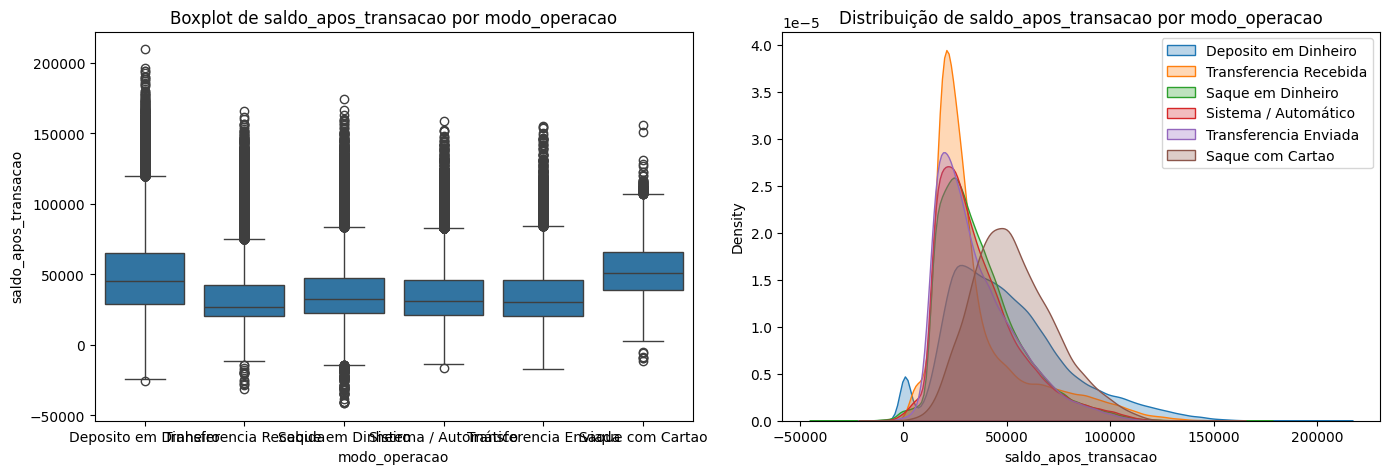

In [42]:
#Aplicação da função

comparar_variavel(transacoes_df, var_quantitativa = 'saldo_apos_transacao', var_categorica='modo_operacao')

#### Mapeando Clientes Ruins e Bons 

In [45]:
# 1. Separamos em uma lista quais são as strings exatas que definem um Bom Pagador
status_bons = ['Encerrado - Quitado', 'Ativo - Regular']

# 2. Criamos a coluna alvo_risco. 
# A lógica é: O status atual está na lista de bons? Se sim, coloque 1. Se não, coloque 0.
emprestimo_df['alvo_risco'] = np.where(emprestimo_df['status_pagamento'].isin(status_bons), 1, 0)

# 3. Vamos visualizar algumas linhas para garantir que a regra foi aplicada corretamente
display(emprestimo_df[['status_pagamento', 'alvo_risco']].sample(10))

,status_pagamento,alvo_risco
42,Ativo - Regular,1
673,Ativo - Regular,1
539,Ativo - Regular,1
4,Encerrado - Quitado,1
416,Ativo - Regular,1
643,Ativo - Regular,1
627,Ativo - Regular,1
560,Ativo - Regular,1
112,Encerrado - Quitado,1
436,Encerrado - Quitado,1


In [61]:

emprestimo_df.sample(5)

,id_emprestimo,id_conta,data,valor_total,prazo_meses,valor_parcela,status_pagamento,alvo_risco
262,6421,6985,1996-07-25,96768,36,2688.0,Ativo - Regular,1
457,5229,1329,1997-09-06,23520,12,1960.0,Encerrado - Quitado,1
572,6682,8225,1998-03-30,36204,12,3017.0,Ativo - Inadimplente,0
321,7154,10520,1996-12-05,417600,60,6960.0,Ativo - Regular,1
444,6097,5362,1997-08-21,202848,48,4226.0,Ativo - Regular,1


In [53]:
# Verificando a porcentagem de Bons (1) e Maus (0) pagadores
proporcao = emprestimo_df['alvo_risco'].value_counts(normalize=True) * 100

print("Proporção da Variável Alvo:")
print(proporcao.round(2).astype(str) + '%')

Proporção da Variável Alvo:
alvo_risco
1    88.86%
0    11.14%
Name: proportion, dtype: str
